# 21 — Window SLA controllers: `sla_pb` vs `sla_mc`

**ADR 0151 / T-164** — both arms invert the same window service-level objective:

> Find the smallest case-rounded order quantity `q` whose **joint** probability of zero
> missed demand across the protection window is at least `α`, then damp with `ρ`.

| Arm | Mechanism | Role |
| --- | --- | --- |
| `sla_mc` | CRN Monte Carlo paths through `protection_sim::simulate_protection_path` | Oracle reference |
| `sla_pb` | Poisson-binomial alive-count PMF × day-joint product on cached survival curves | Fast path for Studio / alpha-tune |

This notebook compares the two controllers **side by side**: single-step orders on belief
snapshots, Monte Carlo path convergence, runtime, and closed-loop episode outcomes on
shared seeds. Notebook 20 widens the bakeoff to include `sw` and `rollout`; here we stay
focused on the PB/MC pair.


## Setup

From the repo root (release PyO3 extension required):

```bash
uv sync --all-extras --python 3.11
uv run --python 3.11 maturin develop --release -m crates/voi_py/Cargo.toml
export BLUEBERRIES_VOI_BACKEND=rust
uv run jupyter lab notebooks/
```

Set `SMOKE=True` for a one-seed, three-day closed-loop smoke run.


In [1]:
%matplotlib inline

from __future__ import annotations

import os
import time
from pathlib import Path

os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")

import matplotlib.pyplot as plt

from blueberries_voi.backend import rust_available, rust_core, warn_fallback_once
from blueberries_voi.sim.alpha_tune import evaluate_alpha_episode_outcomes, require_tuned_alpha_table
from blueberries_voi.sim.order_schedule import DEFAULT_ORDER_SCHEDULE
from blueberries_voi.sim.shipments import smoke_cool_shipments

plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})

warn_fallback_once()
if not rust_available() or rust_core is None:
    raise RuntimeError(
        "Rust backend required. Build with: "
        "uv run maturin develop --release -m crates/voi_py/Cargo.toml"
    )

SMOKE = False
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "blueberries_voi").is_dir():
    REPO_ROOT = REPO_ROOT.parent
FIG_DIR = REPO_ROOT / "notebooks" / "outputs" / "nb21_sla_compare"
FIG_DIR.mkdir(parents=True, exist_ok=True)

schedule = DEFAULT_ORDER_SCHEDULE
ALPHA_TABLE = REPO_ROOT / "experiments" / "tuned_alpha.json"
ALPHA = float(require_tuned_alpha_table(ALPHA_TABLE)["sla_pb"])
RHO = 0.8
ORDER_DAY = 6  # Sunday (first order day in default MWF calendar)
F_GRID = [0.0, 0.25, 0.5, 0.75, 1.0]
CASE = 8
ROOT_SEED = 42

WEEKDAY = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print(
    f"order day {ORDER_DAY} ({WEEKDAY[ORDER_DAY]}), "
    f"protection={schedule.protection_days(ORDER_DAY)}d, α={ALPHA}, ρ={RHO}"
)


order day 6 (Sun), protection=3d, α=0.95, ρ=0.8


## Helpers — single-step orders

Both functions call the same Rust entry points the studio uses in `session.act`.


In [2]:
def sla_pb_order(
    *,
    lot_counts: list[float] | None = None,
    f_marginals: list[float] | None = None,
    f_grid: list[float] | None = None,
    pending_days: list[int] | None = None,
    pending_qtys: list[int] | None = None,
    pending_sum: int = 0,
    day: int = ORDER_DAY,
    alpha: float = ALPHA,
    rho: float = RHO,
    demand_mu: float = 30.0,
    demand_vm: float = 4.0,
    case_size: int = CASE,
    f_pipeline_default: float = 1.0,
) -> int:
    lot_counts = lot_counts or []
    f_marginals = f_marginals or []
    f_grid = f_grid or F_GRID
    pending_days = pending_days or []
    pending_qtys = pending_qtys or []
    return int(
        rust_core.sla_pb_order_f_belief_py(
            lot_counts,
            f_marginals,
            f_grid,
            pending_days,
            pending_qtys,
            pending_sum,
            day,
            alpha,
            rho,
            case_size=case_size,
            demand_mu=demand_mu,
            demand_vm=demand_vm,
            f_pipeline_default=f_pipeline_default,
        )
    )


def sla_mc_order(
    *,
    n_paths: int = 64,
    root_seed: int = ROOT_SEED,
    lot_counts: list[float] | None = None,
    f_marginals: list[float] | None = None,
    f_grid: list[float] | None = None,
    pending_days: list[int] | None = None,
    pending_qtys: list[int] | None = None,
    pending_sum: int = 0,
    day: int = ORDER_DAY,
    alpha: float = ALPHA,
    rho: float = RHO,
    demand_mu: float = 30.0,
    demand_vm: float = 4.0,
    case_size: int = CASE,
    f_pipeline_default: float = 1.0,
) -> int:
    lot_counts = lot_counts or []
    f_marginals = f_marginals or []
    f_grid = f_grid or F_GRID
    pending_days = pending_days or []
    pending_qtys = pending_qtys or []
    return int(
        rust_core.sla_mc_order_f_belief_py(
            lot_counts,
            f_marginals,
            f_grid,
            pending_days,
            pending_qtys,
            pending_sum,
            day,
            alpha,
            rho,
            root_seed,
            n_paths,
            case_size=case_size,
            demand_mu=demand_mu,
            demand_vm=demand_vm,
            f_pipeline_default=f_pipeline_default,
        )
    )


def peaked_belief(n_lots: int, units: int, freshness: float) -> tuple[list[float], list[float]]:
    k = len(F_GRID)
    lot_counts = [float(units)] * n_lots
    f_marginals: list[float] = []
    for _ in range(n_lots):
        row = [0.0] * k
        idx = min(k - 1, int(round(freshness * (k - 1))))
        row[idx] = 1.0
        f_marginals.extend(row)
    return lot_counts, f_marginals


## 1. Shelf-state ladder (didactic low-μ)

With **μ = 4** (much lower than the committed demand profile) the protection target is
small enough that a well-stocked shelf can already meet the window SLA — the controllers
should order **less** than on an empty shelf. This mirrors the Rust unit test
`sla_pb_stocked_shelf_orders_less_than_empty`.


In [3]:
DIDACTIC_MU = 4.0
F_GRID_TOY = [0.0, 0.5, 1.0]
lot_full, fm_full = peaked_belief(n_lots=4, units=4, freshness=1.0)
# remap to 3-bin grid used in the kernel test
fm_full = [0.0, 0.0, 1.0] * 4

scenarios: dict[str, dict] = {
    "empty shelf": {},
    "well stocked": {
        "lot_counts": lot_full,
        "f_marginals": fm_full,
        "f_grid": F_GRID_TOY,
    },
    "pipeline only": {
        "pending_days": [ORDER_DAY + schedule.lead_time_days],
        "pending_qtys": [CASE * 3],
        "pending_sum": CASE * 3,
        "f_grid": F_GRID_TOY,
    },
}

print(f"{'scenario':14} {'sla_pb':>8} {'sla_mc':>8} {'Δ(mc-pb)':>10}")
print("-" * 44)
for name, kw in scenarios.items():
    pb = sla_pb_order(demand_mu=DIDACTIC_MU, **kw)
    mc = sla_mc_order(n_paths=128, demand_mu=DIDACTIC_MU, **kw)
    print(f"{name:14} {pb:8d} {mc:8d} {mc - pb:+10d}")


scenario         sla_pb   sla_mc   Δ(mc-pb)
--------------------------------------------
empty shelf         128      128         +0
well stocked          0       16        +16
pipeline only         0      128       +128


## 2. Where PB and MC can diverge

The fast path replaces path simulation with a **Poisson-binomial** alive-count PMF and
per-day survival lookups. The MC oracle draws demand, spoilage, and pipeline arrivals on
each CRN path. They usually agree at tuned α, but can differ when:

- the shelf is already well covered (orders near zero);
- `α` is high and the binary search sits on a steep part of the estimated `P(no stockout)` curve;
- `n_paths` is small (MC noise).

The table below sweeps `α` on the **well-stocked** toy belief at μ = 4.


In [4]:
alphas = [0.75, 0.85, 0.9, 0.95]
stocked_kw = scenarios["well stocked"]

print(f"{'alpha':>6} {'sla_pb':>8} {'mc(16)':>8} {'mc(128)':>8}")
print("-" * 34)
for a in alphas:
    pb = sla_pb_order(alpha=a, demand_mu=DIDACTIC_MU, **stocked_kw)
    mc16 = sla_mc_order(n_paths=16, alpha=a, demand_mu=DIDACTIC_MU, **stocked_kw)
    mc128 = sla_mc_order(n_paths=128, alpha=a, demand_mu=DIDACTIC_MU, **stocked_kw)
    print(f"{a:6.2f} {pb:8d} {mc16:8d} {mc128:8d}")


 alpha   sla_pb   mc(16)  mc(128)
----------------------------------
  0.75        0        0        0
  0.85        0        0        8
  0.90        0        8        8
  0.95        0        8       16


### MC path convergence

On the **empty** shelf at production μ = 30 both arms typically hit the shared `q` cap
(160 units). For the stocked toy belief, MC orders should stabilize as path count grows.


Wrote /home/oliver/blog/blueberries-voi/notebooks/outputs/nb21_sla_compare/mc_path_convergence.png


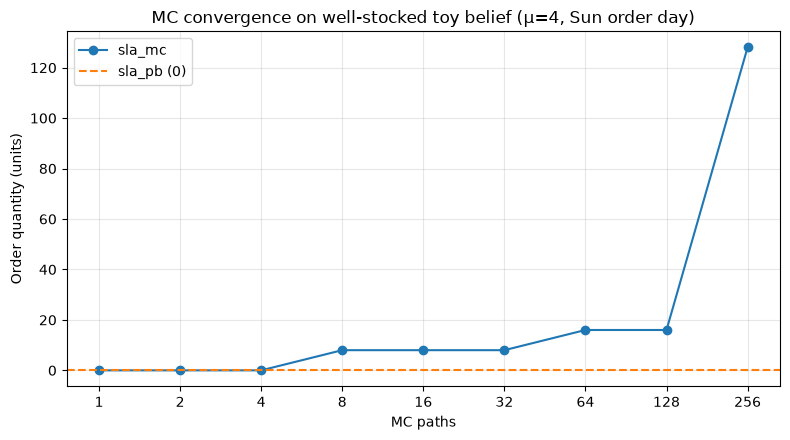

In [5]:
path_counts = [1, 2, 4, 8, 16, 32, 64, 128, 256]
pb_ref = sla_pb_order(demand_mu=DIDACTIC_MU, **stocked_kw)
mc_curve = [
    sla_mc_order(n_paths=n, demand_mu=DIDACTIC_MU, **stocked_kw) for n in path_counts
]

fig, ax = plt.subplots()
ax.plot(path_counts, mc_curve, "o-", label="sla_mc")
ax.axhline(pb_ref, color="C1", ls="--", label=f"sla_pb ({pb_ref})")
ax.set_xscale("log", base=2)
ax.set_xticks(path_counts)
ax.set_xticklabels(path_counts)
ax.set_xlabel("MC paths")
ax.set_ylabel("Order quantity (units)")
ax.set_title("MC convergence on well-stocked toy belief (μ=4, Sun order day)")
ax.legend()
fig.tight_layout()
conv_path = FIG_DIR / "mc_path_convergence.png"
fig.savefig(conv_path, dpi=140)
print(f"Wrote {conv_path}")


## 3. Runtime

Studio defaults: `sla_pb` every 500 ms, `sla_mc` every 1000 ms (`autopilotLoop.ts`).
The micro-benchmark below times single `act`-equivalent order calls (empty shelf, μ=30).


arm             ms/call    vs pb
--------------------------------
sla_pb            23.84      1.0x
sla_mc (8p)        5.55      0.2x
sla_mc (32p)      24.35      1.0x
sla_mc (128p)     108.33      4.5x
Wrote /home/oliver/blog/blueberries-voi/notebooks/outputs/nb21_sla_compare/runtime_bar.png


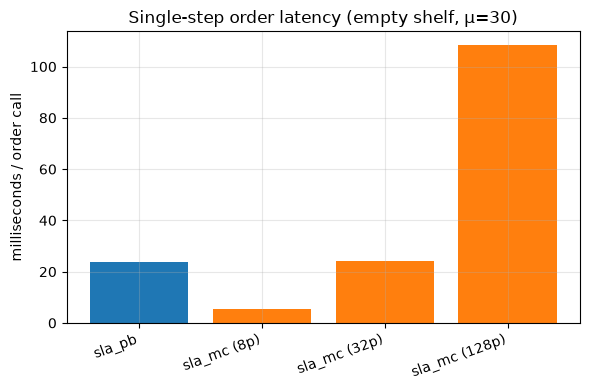

In [6]:
N_REPS = 20 if SMOKE else 40
bench_rows: list[tuple[str, float]] = []

t0 = time.perf_counter()
for _ in range(N_REPS):
    sla_pb_order()
bench_rows.append(("sla_pb", (time.perf_counter() - t0) / N_REPS))

for n_paths in (8, 32, 128):
    t0 = time.perf_counter()
    for _ in range(N_REPS):
        sla_mc_order(n_paths=n_paths)
    bench_rows.append((f"sla_mc ({n_paths}p)", (time.perf_counter() - t0) / N_REPS))

pb_ms = bench_rows[0][1] * 1e3
print(f"{'arm':12} {'ms/call':>10} {'vs pb':>8}")
print("-" * 32)
for label, sec in bench_rows:
    ratio = sec / bench_rows[0][1]
    print(f"{label:12} {sec * 1e3:10.2f} {ratio:8.1f}x")

fig, ax = plt.subplots(figsize=(6, 4))
labels = [r[0] for r in bench_rows]
vals = [r[1] * 1e3 for r in bench_rows]
ax.bar(labels, vals, color=["C0", "C1", "C1", "C1"])
ax.set_ylabel("milliseconds / order call")
ax.set_title("Single-step order latency (empty shelf, μ=30)")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()
rt_path = FIG_DIR / "runtime_bar.png"
fig.savefig(rt_path, dpi=140)
print(f"Wrote {rt_path}")


## 4. Closed-loop episodes (production μ)

Finally, run scored weeks with the Rust alpha-tune harness on **shared seeds**. At tuned
α both arms should land near each other on profit, waste, and lost sales — any gap is
mostly MC variance unless `n_paths` is raised in `EngineSession` config.


In [7]:
SEEDS = (42,) if SMOKE else (42, 7, 101)
N_BURN = 2 if SMOKE else 7
N_SCORE = 3 if SMOKE else 14
ships = smoke_cool_shipments()

episode_rows: list[dict[str, float | int | str]] = []
for arm in ("sla_pb", "sla_mc"):
    for seed in SEEDS:
        t0 = time.perf_counter()
        out = evaluate_alpha_episode_outcomes(
            arm,
            ALPHA,
            seed,
            rho=RHO,
            shipments=ships,
            n_burn=N_BURN,
            n_score=N_SCORE,
        )
        elapsed = time.perf_counter() - t0
        episode_rows.append(
            {
                "arm": arm,
                "seed": seed,
                "profit": out.profit,
                "waste": out.total_waste,
                "lost": out.total_lost_sales,
                "seconds": elapsed,
            }
        )
        print(
            f"{arm:7} seed={seed:4d} profit={out.profit:7.1f} "
            f"waste={out.total_waste:3d} lost={out.total_lost_sales:3d} t={elapsed:5.1f}s"
        )

# profit comparison per seed
print("\nPer-seed profit gap (sla_mc - sla_pb):")
by_seed: dict[int, dict[str, float]] = {}
for row in episode_rows:
    by_seed.setdefault(int(row["seed"]), {})[str(row["arm"])] = float(row["profit"])
for seed, profits in sorted(by_seed.items()):
    gap = profits.get("sla_mc", 0.0) - profits.get("sla_pb", 0.0)
    print(f"  seed {seed:4d}: {gap:+.1f}")


sla_pb  seed=  42 profit=  638.5 waste=161 lost=  0 t=  0.0s
sla_pb  seed=   7 profit=  407.0 waste=306 lost=  0 t=  0.0s
sla_pb  seed= 101 profit=  444.5 waste=257 lost=  0 t=  0.0s
sla_mc  seed=  42 profit=  638.5 waste=161 lost=  0 t=  0.2s
sla_mc  seed=   7 profit=  407.0 waste=306 lost=  0 t=  0.2s
sla_mc  seed= 101 profit=  429.5 waste=267 lost=  0 t=  0.2s

Per-seed profit gap (sla_mc - sla_pb):
  seed    7: +0.0
  seed   42: +0.0
  seed  101: -15.0


## Takeaways

1. **Same objective** — both arms binary-search the smallest `q` with window joint
   no-stockout probability ≥ `α`, then apply `ρ` and case rounding.
2. **`sla_pb` is the production fast path** — analytic Poisson-binomial + cached survival;
   Studio and alpha-tune call it by default.
3. **`sla_mc` is the oracle** — path simulation with stochastic demand, spoilage, and
   pipeline arrivals; use it to validate PB and to study MC variance vs `n_paths`.
4. **Largest single-step gaps** appear when the shelf is already well covered (orders near
   zero) or when MC path count is low — not usually on empty-shelf production μ where both
   hit the shared `q` cap.
5. **Closed-loop profit** at tuned α should track closely on shared seeds; notebook 20
   places both arms on the runtime–accuracy frontier alongside `sw` and `rollout`.

See `docs/control/window-service-level.md` and `crates/voi_core/src/protection_sim.rs`.
